# Filter Functions for Dynamical Decoupling Sequences

This notebook visualizes the filter functions $F(\omega, t)$ for all pulse sequences 
used in this project. The filter function determines which frequencies of the noise 
power spectral density $S(\omega)$ contribute to coherence decay via:

$$\chi(t) = \int_0^\infty \frac{d\omega}{2\pi} S(\omega) F(\omega, t)$$

Different sequences probe different spectral windows — this notebook makes that concrete.

**Reference:** Theory document `03_filter_functions_sequences.tex`

In [ ]:
import sys
sys.path.append('../simulation')
from filter_functions import F_Ramsey, F_Hahn, F_CPMG, F_XY8, F_UDD

## 1. Ramsey and Hahn Echo

Ramsey has no π pulses — it is maximally sensitive to DC and low-frequency noise. 
Hahn echo has one π pulse at t/2 — it refocuses slow noise completely and acts as 
a bandpass filter. The dashed lines show the analytical peak location $2\pi/t$ 
versus the true numerical peak, which is shifted lower by the $1/\omega^2$ denominator.

c:\Users\omaru\Projects\qubit-noise-spectroscopy\notebooks\../simulation\filter_functions.py:4: RuntimeWarning: invalid value encountered in divide
  return np.where(omega == 0, t ** 2, (4 * (np.sin(omega * t / 2) ** 2)) / (omega ** 2))
c:\Users\omaru\Projects\qubit-noise-spectroscopy\notebooks\../simulation\filter_functions.py:7: RuntimeWarning: invalid value encountered in divide
  return np.where(omega == 0, 0 , (16 * (np.sin(omega * t / 4) ** 4) / omega ** 2))


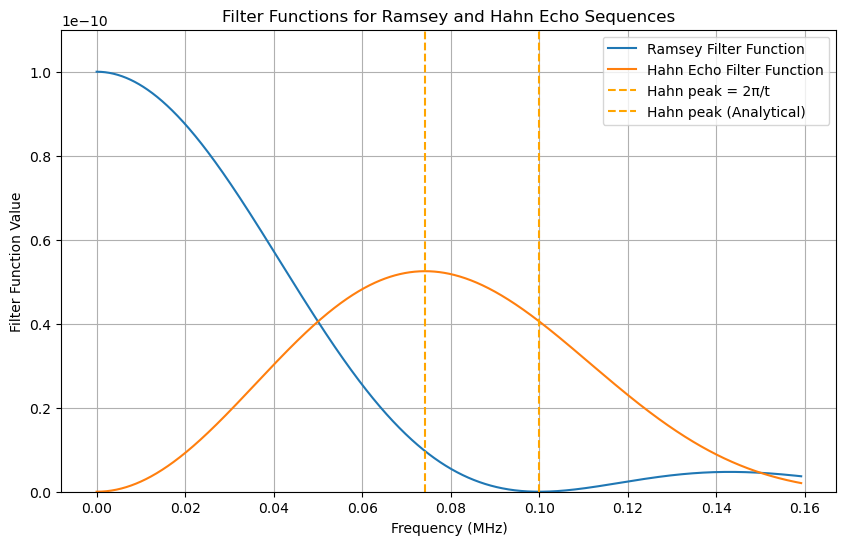

In [2]:
import numpy as np
import matplotlib.pyplot as plt

t = 10e-6
omega = np.linspace(0, 1e6, 1000)
omega_MHz = omega / (2 * np.pi * 1e6)
F_Ramsey_values = F_Ramsey(omega, t)
F_Hahn_values = F_Hahn(omega, t)

plt.figure(figsize=(10, 6))
plt.plot(omega_MHz, F_Ramsey_values, label='Ramsey Filter Function')
plt.plot(omega_MHz, F_Hahn_values, label='Hahn Echo Filter Function')
plt.axvline(x=2*np.pi/t / (2*np.pi*1e6), color='orange', linestyle='--', label='Hahn peak = 2π/t')
plt.axvline(x=omega_MHz[np.argmax(F_Hahn_values)], color='orange', linestyle='--', label='Hahn peak (Analytical)')
plt.xlabel('Frequency (MHz)')
plt.ylabel('Filter Function Value')
plt.title('Filter Functions for Ramsey and Hahn Echo Sequences')
plt.legend()
plt.grid()
plt.ylim(0, max(max(F_Ramsey_values), max(F_Hahn_values)) * 1.1)
plt.show()




## 2. CPMG-n

CPMG-n applies n equally spaced π pulses. As n increases, the filter peak shifts 
to higher frequencies at $\omega \approx n\pi/t$. The peak width is set by the 
total sequence time $t$, not $n$ — more pulses probes higher frequencies, 
longer sequences give better frequency resolution.

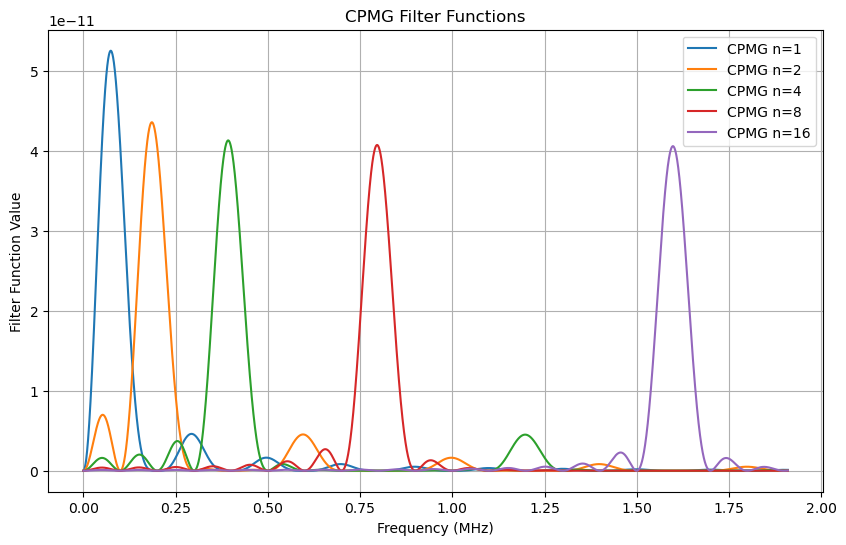

In [6]:
omega = np.linspace(0, 12e6, 10000)
omega_MHz = omega / (2 * np.pi * 1e6)

plt.figure(figsize=(10, 6))
for n in [1, 2, 4, 8, 16]:
    F_CPMG_values = F_CPMG(omega, t, n)
    plt.plot(omega_MHz, F_CPMG_values , label=f'CPMG n={n}')
plt.xlabel('Frequency (MHz)')
plt.ylabel('Filter Function Value')
plt.title('CPMG Filter Functions')
plt.legend()
plt.grid()
plt.show()

## 3. XY-8

XY-8 is CPMG-8 with phase-cycled pulses (X-Y-X-Y-Y-X-Y-X). For dephasing noise 
the filter function is identical to CPMG-8. The advantage over CPMG-8 is robustness 
to pulse errors on real hardware — the phase cycling cancels residual rotation errors 
to first order.

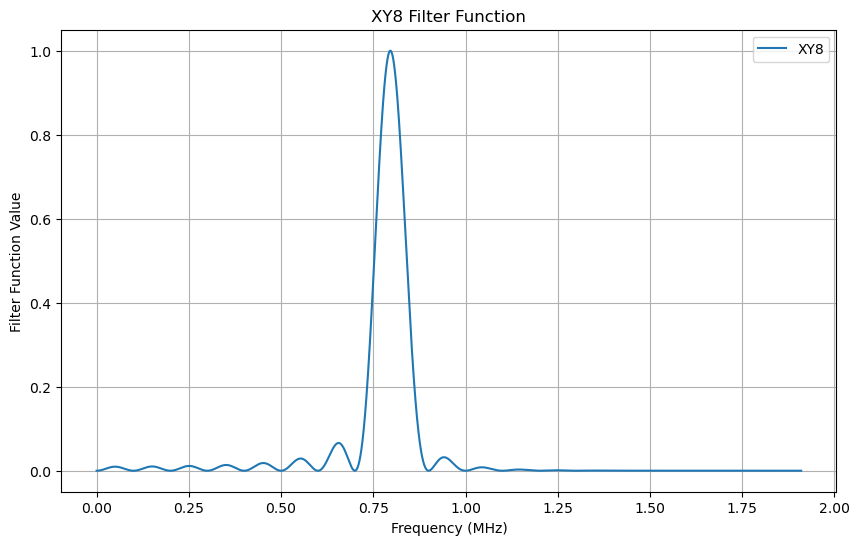

In [5]:
F_XY8_values = F_XY8(omega, t)
plt.figure(figsize=(10, 6))
plt.plot(omega_MHz, F_XY8_values / np.max(F_XY8_values), label='XY8')
plt.xlabel('Frequency (MHz)')
plt.ylabel('Filter Function Value')
plt.title('XY8 Filter Function')
plt.legend()
plt.grid()
plt.show()


## 4. UDD-n (Uhrig Dynamical Decoupling)

UDD places n π pulses at nonuniform times $t_j = t\sin^2(j\pi/2(n+1))$. This spacing 
is optimal for suppressing dephasing to order n for smooth $S(\omega)$. Unlike CPMG, 
no closed-form filter function exists — it must be evaluated numerically. The irregular 
sidelobe structure is the signature of nonuniform pulse spacing.

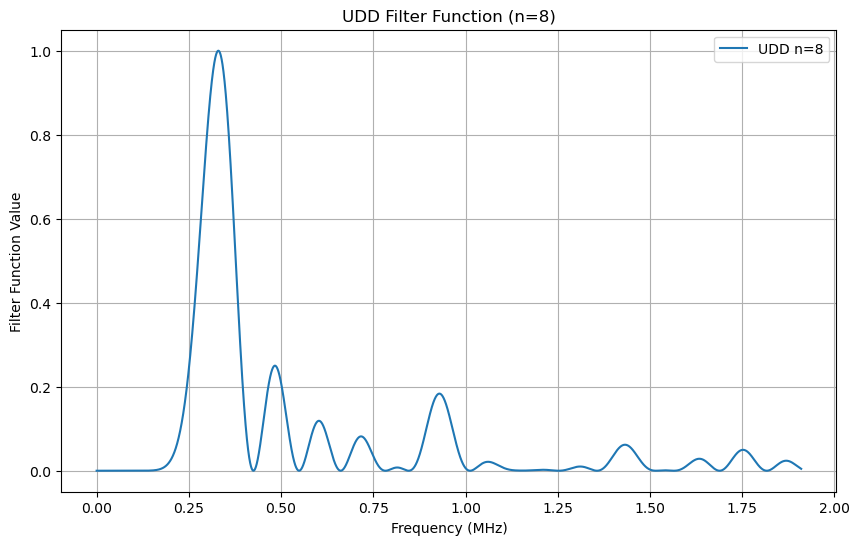

In [7]:
F_UDD_values = F_UDD(omega, t, 8)
plt.figure(figsize=(10, 6))
plt.plot(omega_MHz, F_UDD_values / np.max(F_UDD_values), label='UDD n=8')
plt.xlabel('Frequency (MHz)')
plt.ylabel('Filter Function Value')
plt.title('UDD Filter Function (n=8)')
plt.legend()
plt.grid()
plt.show()


## 5. XY-8 vs UDD-8 Comparison

Both sequences use 8 π pulses but with different spacing. XY-8 (uniform) has a sharp, 
clean peak at $8\pi/t$. UDD-8 (nonuniform) peaks at a lower frequency with broader, 
irregular sidebands. For smooth $S(\omega)$, UDD achieves better suppression. For 
sharp spectral features like TLS peaks, XY-8's cleaner filter is preferred.

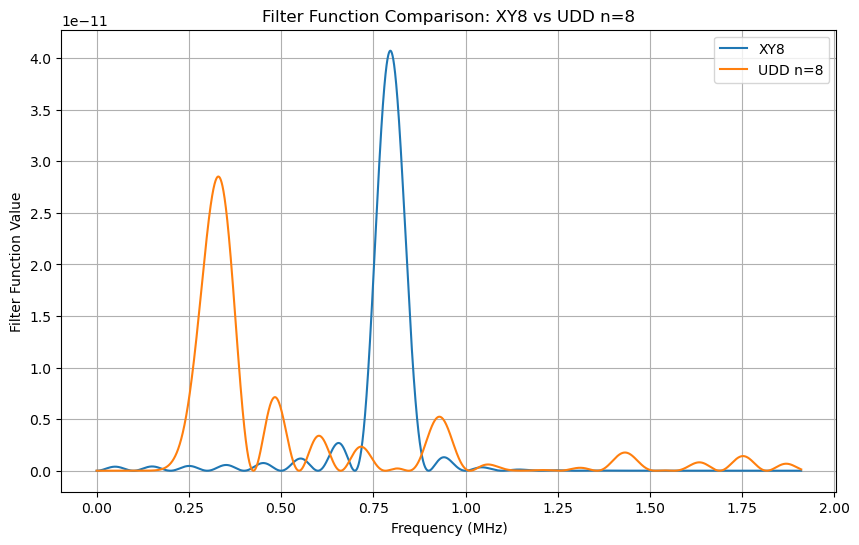

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(omega_MHz, F_XY8_values, label='XY8')
plt.plot(omega_MHz, F_UDD_values, label='UDD n=8')
plt.xlabel('Frequency (MHz)')
plt.ylabel('Filter Function Value')
plt.title('Filter Function Comparison: XY8 vs UDD n=8')
plt.legend()
plt.grid()
plt.show()


## Summary and Discussion

The filter function $F(\omega, t)$ is the central object connecting a pulse sequence 
to its spectral sensitivity. For a given sequence, it maps each noise frequency $\omega$ 
to a weight — frequencies where $F(\omega, t)$ is large contribute strongly to the 
coherence decay $\chi(t)$, while frequencies where it is small are effectively invisible 
to the experiment. Designing a pulse sequence is therefore equivalent to designing a 
spectral filter.

The key distinction between the sequences derived here is their low-frequency behavior. 
Ramsey, with no π pulses, peaks at $\omega = 0$ and is maximally sensitive to slow, 
quasistatic noise — charge noise, flux noise, and other low-frequency fluctuations that 
dominate superconducting qubit environments. The echo sequences (Hahn, CPMG, XY-8, UDD) 
suppress this slow noise through π pulse refocusing, and instead probe faster noise at 
higher frequencies. By varying the number of pulses $n$ and the total sequence time $t$, 
the filter peak can be tuned across the noise spectrum — this is the principle of 
dynamical decoupling-based noise spectroscopy.

The next step is to use these filter functions to compute the coherence decay $\chi(t)$ 
by numerically integrating $S(\omega) F(\omega, t)$ over frequency. This requires a 
model for the noise power spectral density $S(\omega)$ — in simulation we define this 
directly, while on hardware it is the unknown quantity we aim to reconstruct. The 
inversion problem — recovering $S(\omega)$ from measured $\chi(t)$ — is the core of 
the spectroscopy pipeline and is addressed in notebooks 02 and 03.